In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

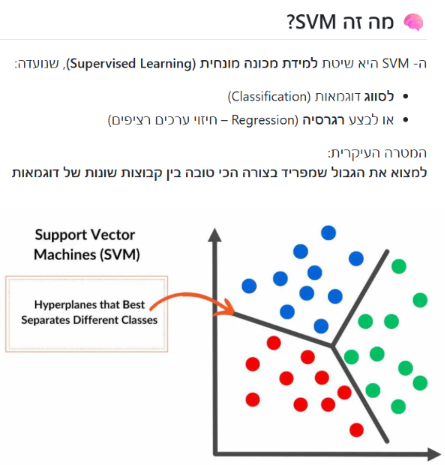

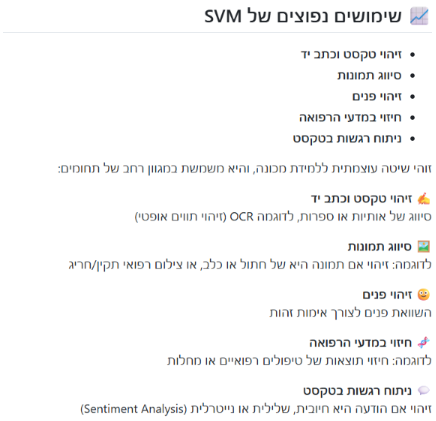

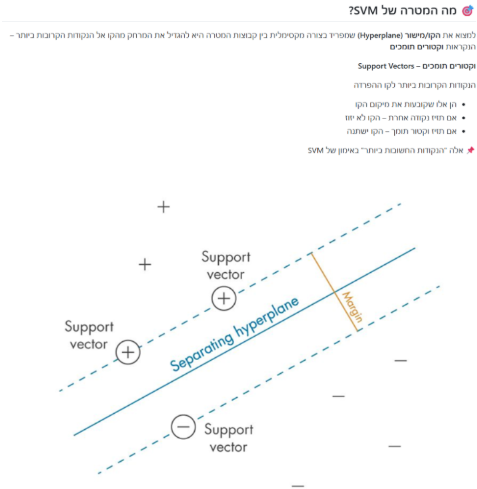

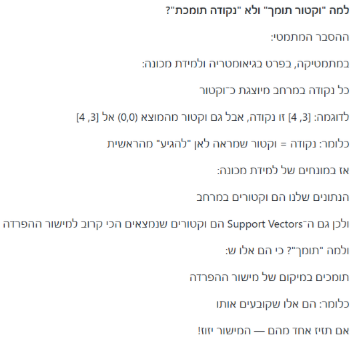

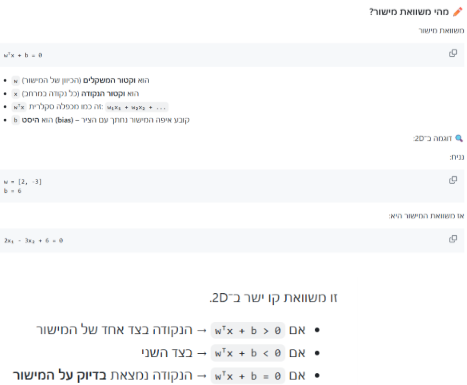

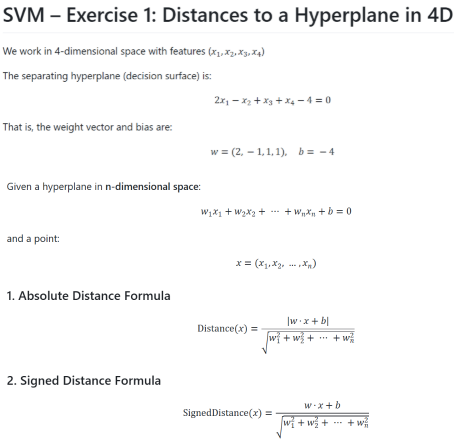

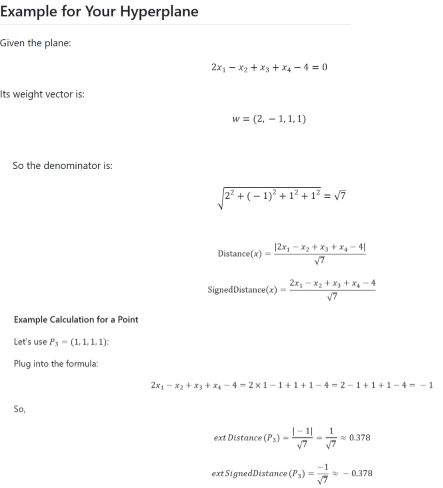

In [2]:
# P3 = (1, 1, 1, 1)

# w = (2, −1, 1, 1), b = −4
# 2x1 - x2 + x3 + x4 - 4 = 0
# mehane = sqrt(7)
# 2*1 -1*1 +1*1 +1*1 -4 = -1

# abs-distance    = +1 / sqrt(7) = 0.378
# signal-distance = -1 / sqrt(7) = ~ -0.378

# is below the hyperplane 

In [3]:
import numpy as np

# 10 points 
points = np.array([
    [0, 0, 0, 0],   # P1
    [2, 0, 0, 0],   # P2
    [1, 1, 1, 1],   # P3
    [3, -1, 0, 2],  # P4
    [0, 2, 1, 1],   # P5
    [4, 1, -1, 0],  # P6
    [1, 0, 2, 1],   # P7
    [2, 1, 0, 3],   # P8
    [0, -1, 0, 3],  # P9
    [3, 2, 1, 0],   # P10
], dtype=float)

w = np.array([2, -1, 1, 1])
w_norm = np.sqrt(sum(num**2 for num in w))
b = -4.0
   
def get_signed_distance(point, w, b):
    numerator = np.dot(point, w) + b
    denomerator = w_norm
    return numerator / denomerator

def get_abs_distance(point, w, b):
    numerator = np.abs(np.dot(point, w) + b)
    denomerator = w_norm
    return numerator / denomerator
    
for i in range(len(points)):
    pt = points[i]
    display_num = i + 1
    print(f'\n--------------- point {display_num} ---------------')
    print(f'signal-distance {display_num} -> {get_signed_distance(pt, w, b)}')
    print(f'abs-distance  {display_num} -> +{get_abs_distance(pt, w, b)}')


--------------- point 1 ---------------
signal-distance 1 -> -1.5118578920369088
abs-distance  1 -> +1.5118578920369088

--------------- point 2 ---------------
signal-distance 2 -> 0.0
abs-distance  2 -> +0.0

--------------- point 3 ---------------
signal-distance 3 -> -0.3779644730092272
abs-distance  3 -> +0.3779644730092272

--------------- point 4 ---------------
signal-distance 4 -> 1.889822365046136
abs-distance  4 -> +1.889822365046136

--------------- point 5 ---------------
signal-distance 5 -> -1.5118578920369088
abs-distance  5 -> +1.5118578920369088

--------------- point 6 ---------------
signal-distance 6 -> 0.7559289460184544
abs-distance  6 -> +0.7559289460184544

--------------- point 7 ---------------
signal-distance 7 -> 0.3779644730092272
abs-distance  7 -> +0.3779644730092272

--------------- point 8 ---------------
signal-distance 8 -> 0.7559289460184544
abs-distance  8 -> +0.7559289460184544

--------------- point 9 ---------------
signal-distance 9 -> 0.0
abs

In [4]:
import numpy as np

# w = (2, −1, 1, 1), b = −4

# 10 points 
points = np.array([
    [0, 0, 0, 0],   # P1
    [2, 0, 0, 0],   # P2
    [1, 1, 1, 1],   # P3
    [3, -1, 0, 2],  # P4
    [0, 2, 1, 1],   # P5
    [4, 1, -1, 0],  # P6
    [1, 0, 2, 1],   # P7
    [2, 1, 0, 3],   # P8
    [0, -1, 0, 3],  # P9
    [3, 2, 1, 0],   # P10
], dtype=int)

w1, w2, w3, w4, b = 2, -1, 1, 1, -4

def get_signed_distance(point, w1, w2, w3, w4, b):  # or w: list[]
    x1, x2, x3, x4 = point
    numerator = x1 * w1 + x2 * w2 + x3 * w3 + x4 * w4 + b
    # denominator = np.linalg.norm(np.array([w1, w2, w3, w4]))
    denominator = np.sqrt(w1**2 + w2**2 + w3**2 + w4**2)  # = np.linalg.norm
    vec_dist = numerator / denominator
    return vec_dist
    
def get_abs_distance(point, w1, w2, w3, w4, b):  # or w: list[]
    return np.abs(get_signed_distance(point, w1, w2, w3, w4, b))

counter = 1
for point in points:
    print(f'P{counter:<2}: {str(point):^22} signed_dist = {get_signed_distance(point, w1, w2, w3, w4, b):+.3f}')
    counter += 1

P1 :       [0 0 0 0]        signed_dist = -1.512
P2 :       [2 0 0 0]        signed_dist = +0.000
P3 :       [1 1 1 1]        signed_dist = -0.378
P4 :     [ 3 -1  0  2]      signed_dist = +1.890
P5 :       [0 2 1 1]        signed_dist = -1.512
P6 :     [ 4  1 -1  0]      signed_dist = +0.756
P7 :       [1 0 2 1]        signed_dist = +0.378
P8 :       [2 1 0 3]        signed_dist = +0.756
P9 :     [ 0 -1  0  3]      signed_dist = +0.000
P10:       [3 2 1 0]        signed_dist = +0.378


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create sample data: two groups of (x, y) points
group_a = np.array([ [1, 2], [1.5, 3], [2, 2.5], [2.5, 3.5] ])
group_b = np.array([ [5, 5], [5.5, 6], [6, 5.5], [6.5, 6.5] ])

# Combine into training data
points = np.vstack([group_a, group_b])
labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 0 for group A, 1 for group B

def get_signed_distance(point, w1, w2, b):  # or w: list[]
    x1, x2 = point
    numerator = x1 * w1 + x2 * w2 + b
    # denominator = np.linalg.norm(np.array([w1, w2, w3, w4]))
    denominator = np.sqrt(w1**2 + w2**2)  # = np.linalg.norm
    vec_dist = numerator / denominator
    return vec_dist
    
def get_abs_distance(point, w1, w2, b):  # or w: list[]
    return np.abs(get_signed_distance(point, w1, w2, b))

w1 = np.linspace(-5, 5, 100)
# w2 will be -1
b = np.linspace(-10, 20, 100)

largest_distance_from_min = -1  # the largest distance from the closest point
best_w1 = None
best_b = None
for w1_current in w1:
    for b_current in b:
        # step 1 check if all points are in he correct side
        # signed_distance
        # if label == 0 --> get_signed_distance (negative)
        # if label == 1 --> get_signed_distance (positive)
        # if 1 point does not match --> continue
        # save the line
        distances = []
        valid = True
        for point in group_a:
            dist = get_signed_distance(point, w1_current, -1, b_current)
            # should be negative, if positive -- the line is invalid
            if dist >= 0:
                valid = False
                break
            else:
                distances.append(abs(dist))
        if not valid:
            continue
            
        for point in group_b:
            dist = get_signed_distance(point, w1_current, -1, b_current)
            # should be positive, if negative -- the line is invalid
            if dist <= 0:
                valid = False
                break
            else:
                distances.append(abs(dist))
        if not valid:
            continue   

        # step 2 - find the closest point to this surface
        # place all disatnces in a list and choose the minimum
        closest_point_distance = min(distances)  # closest point to the surface
        if closest_point_distance > largest_distance_from_min:
            largest_distance_from_min = closest_point_distance
            best_w1 = w1_current
            best_b = b_current

print('w1', best_w1)
print('w2', -1)
print('b', best_b)
print(largest_distance_from_min)

w1 3.787878787878787
w2 -1
b -10.0
1.005548803070833


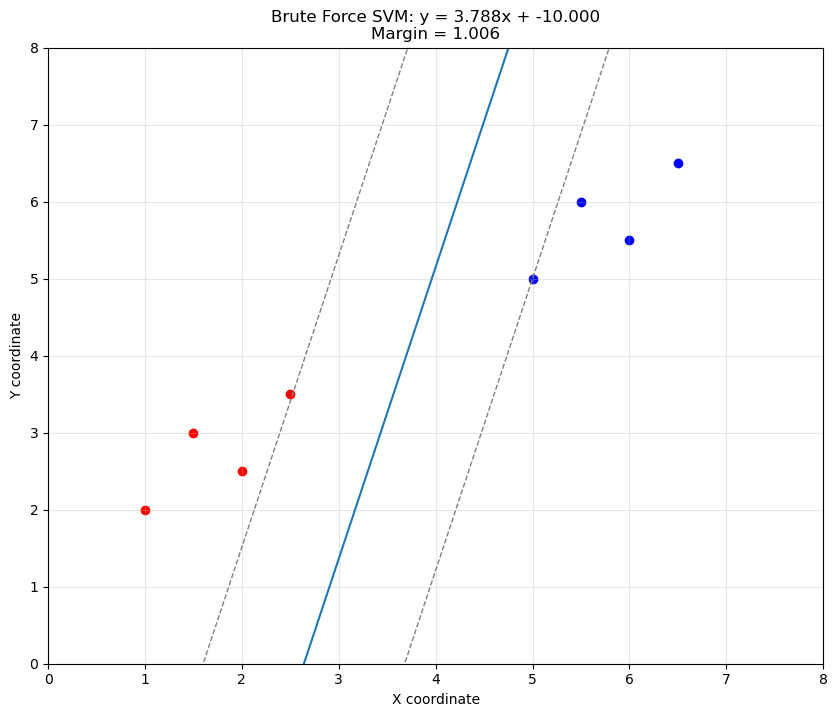

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Brute Force SVM: y = {best_w1:.3f}x + {best_b:.3f}\nMargin = {largest_distance_from_min:.3f}')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)

line_x = np.linspace(0, 10, 10)
line_y = best_w1 * line_x + best_b
ax.plot(line_x, line_y)


ax.scatter(group_a[: , 0], group_a[: , 1], color='red')
ax.scatter(group_b[: , 0], group_b[: , 1], color='blue')

offset = largest_distance_from_min * np.sqrt(best_w1**2 + (-1)**2)

# Upper margin line
y_upper = best_w1 * line_x + (best_b + offset)
ax.plot(line_x, y_upper, 'gray', linewidth=1, linestyle='--', label='Margin')

# Lower margin line
y_lower = best_w1 * line_x + (best_b - offset)
ax.plot(line_x, y_lower, 'gray', linewidth=1, linestyle='--')

plt.show()

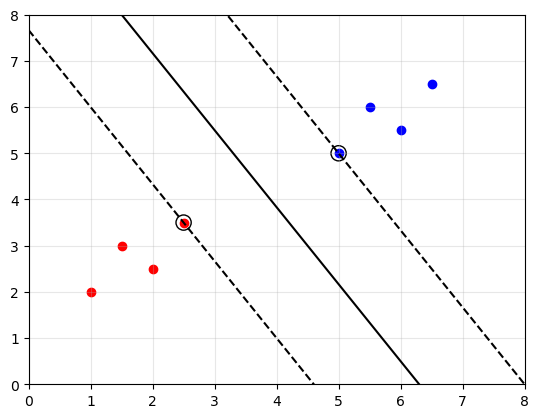

[0.58823529 0.35294118]
-3.705882352941176


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Create sample data: two groups of (x, y) points
group_a = np.array([[1, 2], [1.5, 3], [2, 2.5], [2.5, 3.5]])
group_b = np.array([[5, 5], [5.5, 6], [6, 5.5], [6.5, 6.5]])

# Combine into training data
points = np.vstack([group_a, group_b])
labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 0 for group A, 1 for group B

clf = SVC(kernel='linear')
clf.fit(points, labels)

w = clf.coef_[0]
b = clf.intercept_[0]

y_pred = clf.predict([[1, 2]])  # Important


################################### DISPLAY #######################################
best_slope = -(w[0]/w[1])
best_intercept = (-b / w[1])

# Decision boundary
line_x = np.linspace(0, 8, 100)
line_y = best_slope * line_x + best_intercept

# Margin lines (always ±1 with sklearn)
# w1*x + w2*y + b = 1
# w2*y = -w1*x - b + 1
# y = -(w1/w2)*x - b/w2 + (1/w2)
# y = -(w1/w2)*x - b/w2 
y_up = line_y + 1 / w[1]
y_down = line_y - 1 / w[1]

# --- Plot ---
plt.scatter(group_a[:, 0], group_a[:, 1], color="red")
plt.scatter(group_b[:, 0], group_b[:, 1], color="blue")
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            edgecolors="black", facecolors="none", s=120)

plt.plot(line_x, line_y, "k")       # decision boundary
plt.plot(line_x, y_up, "k--")       # margin
plt.plot(line_x, y_down, "k--")     # margin

plt.xlim(0, 8)
plt.ylim(0, 8)
plt.grid(True, alpha=0.3)
plt.show()
# Ax + By + c = 0
# Ax + c = By
# A/B * x + c/B
# 0.58823529 * X + 0.35 * Y - 3.7 = 0
# 
print(w) 
print(b)

In [8]:
# evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = clf.predict(points)

cm = confusion_matrix(labels, y_pred)
print("prediction:", y_pred)
print("true:      ", y_pred)
print()
print("Confusion matrix:\n", cm)

print("Accuracy:", accuracy_score(labels, y_pred))

print("Classification Report:\n")
print(classification_report(labels, y_pred))

prediction: [0 0 0 0 1 1 1 1]
true:       [0 0 0 0 1 1 1 1]

Confusion matrix:
 [[4 0]
 [0 4]]
Accuracy: 1.0
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

